# Lista 5

## Pandas i Dask

(8pkt + 2pkt)

Na liÅ›cie znajduje siÄ™ 8 zadaÅ„. Po rozwiÄ…zaniu zadania pokaÅ¼ kod prowadzÄ…cemu i odpowiedz na **pytanie kontrolne** â€” tylko wtedy przyznajemy punkty. Dodatkowo przeÅ›lij zadanie na platformie skos.

Zadanie dodatkowe oznaczone jest â­ï¸. Za wykonanie zadania otrzymasz 2pkt.

### Pandas

RozwaÅ¼ bazÄ™ danych z wykÅ‚adu i rozwiÄ…Å¼ poniÅ¼sze zadania.

In [172]:
import numpy as np
import pandas as pd

N = 100000
np.random.seed(123)
data_ = np.random.randint(1000, size=(N, 4))

df = pd.DataFrame(data_, columns=["time", "uid", "pid", "rating"])
df["time"] = np.random.randint(24 * 60 * 60, size=(N))
df["time"] = pd.to_datetime("2025-01-01") + pd.to_timedelta(1e9 * df["time"])
df["rating"] = np.random.randint(10, size=(N))

df.head()

,time,uid,pid,rating
0,2025-01-01 19:32:35,365,382,8
1,2025-01-01 02:23:55,98,742,0
2,2025-01-01 12:11:17,106,123,7
3,2025-01-01 07:07:29,737,96,8
4,2025-01-01 20:31:12,47,73,2


#### Zadanie 1

Dla kaÅ¼dego uÅ¼ytkownika znajdÅº produkt (`pid`), ktÃ³ry oceniÅ‚ najczÄ™Å›ciej.

In [173]:
tmp_df = df.groupby(["uid", "pid"])["pid"].value_counts().reset_index()
idx = tmp_df.groupby("uid")["count"].idxmax()
result = tmp_df.loc[idx]
print(result[["uid", "count"]].reset_index(drop=True))

     uid  count
0      0      2
1      1      3
2      2      2
3      3      3
4      4      2
..   ...    ...
995  995      2
996  996      2
997  997      2
998  998      2
999  999      2

[1000 rows x 2 columns]


#### Zadanie 2

Policz liczbÄ™ ocen w kaÅ¼dej godzinie dnia.

**WskazÃ³wka**

UÅ¼yj `resample()`.

In [174]:
df["hour"] = df["time"].dt.hour
df.groupby(["hour"])["rating"].count()

hour
0     4172
1     4046
2     4183
3     4021
4     4053
5     4132
6     4231
7     4115
8     4221
9     4168
10    4217
11    4168
12    4162
13    4191
14    4187
15    4190
16    4180
17    4215
18    4192
19    4242
20    4185
21    4168
22    4162
23    4199
Name: rating, dtype: int64

#### Zadanie 3

Wybierz oceny uÅ¼ytkownikÃ³w w godzinach pracy: od 8:00 do 16:00. NastÄ™pnie dla kaÅ¼dego produktu (`pid`) policz: liczbÄ™ ocen, Å›redniÄ… i maksymalnÄ… ocenÄ™.

In [175]:
tmp = df[df["hour"].between(8, 16)]
tmp2 = tmp.groupby("pid")["rating"].agg(["count", "mean", "max"])
print(tmp2)

     count      mean  max
pid                      
0       44  4.818182    9
1       33  4.969697    9
2       42  5.380952    9
3       34  4.205882    9
4       36  4.861111    9
..     ...       ...  ...
995     40  4.600000    9
996     36  3.722222    9
997     40  4.800000    9
998     35  4.857143    9
999     40  4.550000    9

[1000 rows x 3 columns]


#### Zadanie 4

PrzeksztaÅ‚Ä‡ kolumnÄ™ `rating` na sÅ‚owa:

* 0â€“3 â†’ "niska"
* 4â€“6 â†’ "Å›rednia"
* 7â€“9 â†’ "wysoka"

**WskazÃ³wka**

UÅ¼yj `map()`.

In [176]:
def rating_label(x):
    if x <= 3:
        return "niska"
    elif x <= 6:
        return "średnia"
    else:
        return "wysoka"
    
df["word_rating"] = df["rating"].map(rating_label)
df[["rating", "word_rating"]]

,rating,word_rating
0,8,wysoka
1,0,niska
2,7,wysoka
3,8,wysoka
4,2,niska
...,...,...
99995,4,średnia
99996,3,niska
99997,0,niska
99998,5,średnia


#### Zadanie 5

PoÅ‚Ä…cz tabelÄ™ *products* zawierajÄ…cÄ… nazwy produktÃ³w (`pid` â†’ `product_name`) z gÅ‚Ã³wnym df.

In [177]:
products = pd.DataFrame({
    'pid': df['pid'].unique(),
    'product_name': ['Produkt_' + str(i) for i in range(len(df['pid'].unique()))]
})

df.merge(products)


,time,uid,pid,rating,hour,word_rating,product_name
0,2025-01-01 19:32:35,365,382,8,19,wysoka,Produkt_0
1,2025-01-01 02:23:55,98,742,0,2,niska,Produkt_1
2,2025-01-01 12:11:17,106,123,7,12,wysoka,Produkt_2
3,2025-01-01 07:07:29,737,96,8,7,wysoka,Produkt_3
4,2025-01-01 20:31:12,47,73,2,20,niska,Produkt_4
...,...,...,...,...,...,...,...
99995,2025-01-01 09:33:24,360,407,4,9,średnia,Produkt_227
99996,2025-01-01 01:58:02,966,924,3,1,niska,Produkt_808
99997,2025-01-01 13:56:17,35,619,0,13,niska,Produkt_779
99998,2025-01-01 02:29:07,976,176,5,2,średnia,Produkt_10


#### Zadanie 6

Policz, ktÃ³re produkty byÅ‚y najczÄ™Å›ciej oceniane w poszczegÃ³lnych godzinach. Zwizualizuj to na wykresie.

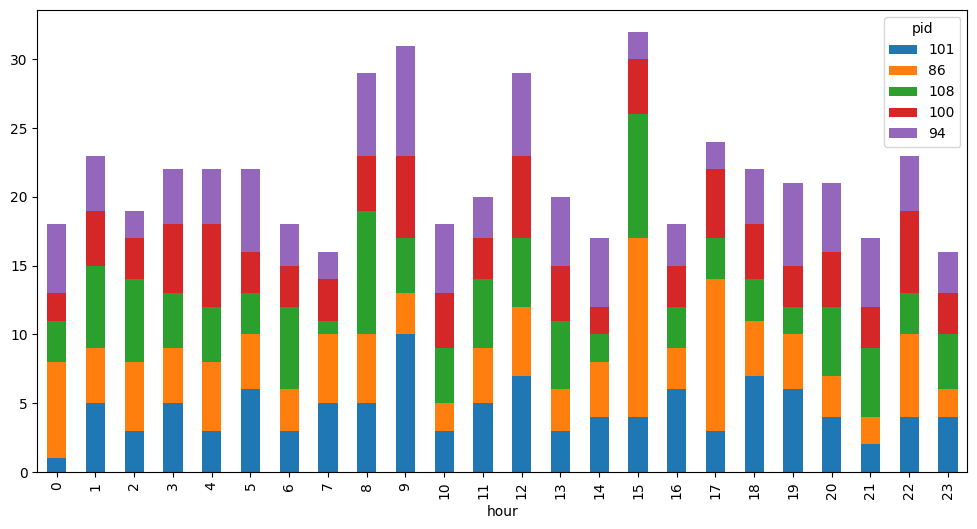

In [178]:
import matplotlib.pyplot as plt

counts = df.groupby(["pid", "hour"]).size().unstack(fill_value=0)

top_products = counts.sum(axis=1).head(5)
counts.loc[top_products].T.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.show()


#### Zadanie 7

UtwÃ³rz dla kaÅ¼dego uÅ¼ytkownika sekwencjÄ™ identyfikatorÃ³w produktÃ³w (`pid`), ktÃ³re oceniÅ‚, ale tylko produkty ocenione wiÄ™cej niÅ¼ 50 razy w godzinach od 8:00 do 16:00.

**WskazÃ³wka**

GodzinÄ™ moÅ¼esz wyodrÄ™bniÄ‡ za pomocÄ…:

```python
df['time'].dt.hour
```

In [179]:
tmp = df[df["hour"].between(8, 16)]

popular_pids = tmp.groupby("pid").filter(lambda x: len(x) > 50)["pid"].unique()
df_filtered = tmp[tmp["pid"].isin(popular_pids)]

df_filtered.groupby("uid")["pid"].apply(list).head()


uid
1       [903, 867, 199]
2                 [514]
3    [644, 514, 7, 600]
4       [903, 514, 588]
7                 [217]
Name: pid, dtype: object

#### Zadanie 8

Podziel produkty na 3 grupy wedÅ‚ug â€žstabilnoÅ›ci ocenâ€ (liczba ocen produktu) i policz Å›redniÄ… ocenÄ™ dla kaÅ¼dego uÅ¼ytkownika w kolejnych godzinach dnia, ale tylko dla produktÃ³w naleÅ¼Ä…cych do 3. grupy (produkty z najwiÄ™kszÄ… liczbÄ… ocen).

**WskazÃ³wka**

MoÅ¼e siÄ™ przydaÄ‡ funkcja `qcut()`, `merge()`.

In [180]:
df['hour'] = df['time'].dt.hour
product_counts = df.groupby('pid').size()
labels = pd.qcut(product_counts, q=3, labels=[1, 2, 3])
product_group = pd.DataFrame({'pid': product_counts.index, 'group': labels.values})

df = df.merge(product_group, on='pid', how='left')
group3 = df[df['group'] == 3]

result = group3.groupby(['uid', 'hour'])['rating'].mean().unstack(fill_value=0)
result.head()


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
uid,,,,,,,,,,,,,,,,,,,,,
0,5.500000,2.0,0.000000,0.0,2.00,2.000000,6.0,5.0,4.500000,6.50,...,1.500000,7.0,6.000000,0.0,0.0,6.333333,1.00,6.500000,9.0,0.000000
1,0.000000,3.0,7.500000,0.0,5.00,6.000000,1.5,4.5,4.333333,1.00,...,8.000000,4.0,2.000000,3.0,1.0,3.000000,0.00,1.500000,7.0,4.333333
2,0.000000,7.5,4.666667,0.0,2.25,4.333333,2.0,3.0,7.000000,5.00,...,5.500000,5.0,4.000000,8.0,6.0,0.500000,3.25,5.500000,3.0,5.000000
3,0.000000,6.5,3.000000,0.0,8.00,1.000000,0.0,9.0,0.000000,3.75,...,1.000000,7.0,8.666667,4.0,2.0,7.000000,3.50,0.000000,3.5,0.000000
4,4.666667,4.0,4.500000,0.0,4.00,7.000000,2.0,6.5,0.000000,0.50,...,2.666667,0.0,0.000000,0.5,3.5,6.000000,8.00,2.333333,0.0,5.000000


### â­ï¸ Dask

Wygenerujemy dane syntetyczne w Pandas i zapiszemy je do CSV.

In [181]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1_000_000

df = pd.DataFrame({
    "uid": np.random.randint(1, 100_000, size=n),
    "movie_id": np.random.randint(1, 5000, size=n),
    "rating": np.random.uniform(1, 5, size=n).round(2),
    "timestamp": pd.date_range("2020-01-01", periods=n, freq="min")
})

df.to_csv("ratings.csv", index=False)
print("Zapisano plik: ratings.csv")

Zapisano plik: ratings.csv


#### Zadanie 1 

Wczytaj dane z pliku *ratings.csv* do Dask DataFrame. Ile partycji ma wczytany plik? SprawdÅº rozmiar danych (`memory_usage()`)

#### Zadanie 2

Oblicz Å›redniÄ… ocenÄ™ oraz policz liczbÄ™ ocen > 4.

#### Zadanie 3

PokaÅ¼, jak Dask rozkÅ‚ada obliczenia na taski dla operacji:

```python
ddf.groupby("uid")["rating"].mean()
```

#### Zadanie 4

ZnajdÅº 10 filmÃ³w z najwyÅ¼szÄ… Å›redniÄ… ocenÄ… (tylko jeÅ›li majÄ… >100 ocen). Niech wynik bÄ™dzie zapisany w pamiÄ™ci.